In [270]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [271]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # to do things like a + 1
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            # += because we want to accumulate gradients if a Value is use multiple times
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'only supporting int/float powers for now'
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1.0 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    # Simple backprop solution using recursion 
    # but you have to define the inital gradient 1.0 outside or use set_grad=True
    def backprop(self, set_grad):
        if set_grad:
            self.grad = 1.0
        self._backward()
        for node in self._prev:
            node.backprop(False)
    
    # Topological sort version (as shown in Andrej's lecture)
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for c in v._prev:
                    build_topo(c)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [272]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is the result of some operation, add a node for the operation
            dot.node(name=uid + n._op, label=n._op)
            # and connect the operation to the value
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


In [273]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'
# o.backprop(True) # same answer as below
o.backward()


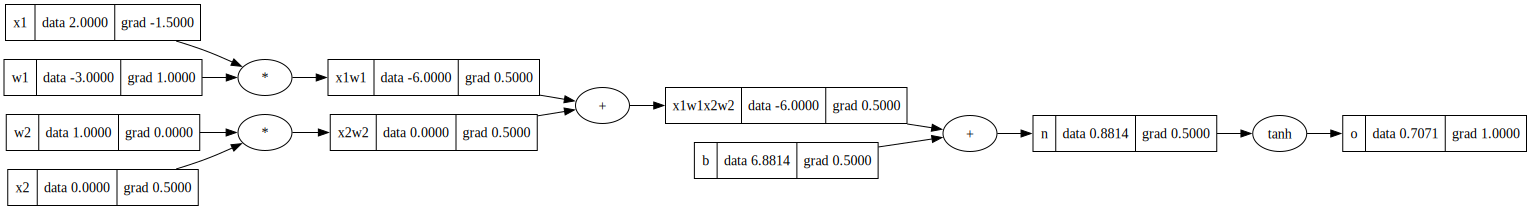

In [274]:
draw_dot(o)

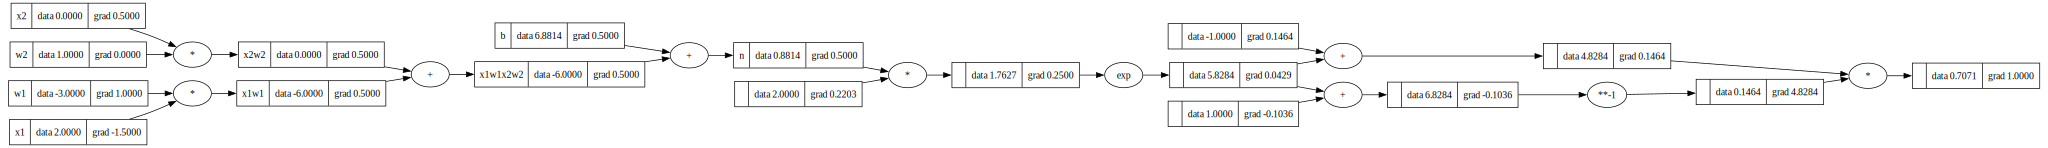

In [275]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'
n = x1w1x2w2 + b; n.label='n'
# ----
# o = n.tanh(); o.label='o'
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
# o.backprop(True) # same answer as below
o.backward()
draw_dot(o)

In [276]:
import torch

x1 = torch.Tensor([2.0]).double();                   x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();                   x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();                  w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();                   w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double();     b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [517]:
import random

class Neuron:

    def __init__(self, num_inputs):
        self.w = [Value(random.uniform(-1,1)) for _ in range(num_inputs)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, num_inputs, num_outputs):
        self.neurons = [Neuron(num_inputs) for _ in range(num_outputs)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, num_inputs, num_outputs): #num_outputs is a list of numbers for each layer 
        sz = [num_inputs] + num_outputs
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(num_outputs))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [518]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x) # __call__ is called here

Value(data=-0.8594864494035385)

In [519]:
len(n.parameters())

41

In [520]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [573]:
# Training Loop
for k in range(100):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # gradient descent (update weights)
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)

0 0.0005613342428282396
1 0.0005603292591597079
2 0.0005593278605122306
3 0.000558330027768643
4 0.0005573357419472764
5 0.0005563449842007819
6 0.0005553577358149511
7 0.0005543739782075144
8 0.0005533936929270169
9 0.0005524168616516497
10 0.0005514434661881092
11 0.0005504734884704884
12 0.0005495069105591721
13 0.0005485437146397155
14 0.0005475838830217499
15 0.0005466273981379415
16 0.0005456742425428834
17 0.0005447243989120715
18 0.0005437778500408496
19 0.0005428345788433673
20 0.0005418945683515519
21 0.0005409578017141372
22 0.0005400242621956256
23 0.0005390939331752732
24 0.0005381667981461697
25 0.000537242840714232
26 0.0005363220445972481
27 0.0005354043936238961
28 0.0005344898717328714
29 0.0005335784629718878
30 0.0005326701514967819
31 0.0005317649215705979
32 0.0005308627575626922
33 0.0005299636439478112
34 0.0005290675653052432
35 0.0005281745063179036
36 0.0005272844517714825
37 0.0005263973865536072
38 0.0005255132956529379
39 0.0005246321641583837
40 0.0005237

In [574]:
ypred

[Value(data=0.990425915915358),
 Value(data=-0.9959052361407518),
 Value(data=-0.9865185765594008),
 Value(data=0.9863438291915112)]